# 🎯 Capstone Project: Smart Influencer Matching untuk UMKM
---
| | |
|---|---|
| **Nama Proyek** | Smart Influencer Matching & Budget Optimizer |
| **Dataset** | Indorse Management — KOL Database (Instagram & TikTok) |
| **Tools** | Python, Google Colab, Streamlit |
| **Platform** | Instagram & TikTok |

---
> **Deskripsi Singkat:**  
> Proyek ini membangun sistem berbasis data untuk membantu UMKM memilih influencer  
> yang relevan dan mengalokasikan anggaran kampanye secara optimal,  
> menggantikan proses pemilihan manual yang tidak efisien.


---
# Tahap 1 — Problem Discovery
> Mengumpulkan dan menganalisis berbagai permasalahan, kemudian menentukan satu solusi utama yang akan dikembangkan dalam proyek.


## 1.1 Key Questions

**What**  
UMKM mengalami kesulitan dalam memilih influencer yang relevan dan berkualitas serta tidak memiliki panduan dalam mengalokasikan anggaran kampanye secara optimal.

**Who**  
Pelaku UMKM yang ingin memanfaatkan influencer marketing namun tidak memiliki tools berbasis data untuk mendukung pengambilan keputusan.

**Where**  
Pada platform media sosial seperti Instagram dan TikTok, di mana proses pemilihan influencer masih dilakukan secara manual tanpa analisis data.

**Why**  
Kesalahan dalam memilih influencer dan mengalokasikan anggaran dapat menyebabkan pemborosan biaya, rendahnya ROI, serta menghambat pertumbuhan bisnis UMKM.

## 1.2 Background
Dalam era digital saat ini, pemasaran melalui influencer menjadi salah satu strategi utama bagi UMKM untuk meningkatkan jangkauan pasar dan penjualan. Namun, banyak UMKM masih menghadapi kesulitan dalam menentukan influencer yang tepat untuk diajak bekerja sama.

Permasalahan ini muncul karena tidak adanya sistem berbasis data yang dapat membantu mengevaluasi kualitas dan relevansi influencer secara objektif. Akibatnya, keputusan yang diambil sering kali bersifat subjektif dan berisiko menyebabkan pemborosan anggaran serta rendahnya Return on Investment (ROI).

## 1.3 Identified Problems
Berdasarkan analisis awal, terdapat beberapa permasalahan yang dihadapi oleh UMKM:
1. Sulit mengidentifikasi influencer dengan audiens yang sesuai dengan target pasar.
2. Tidak tersedia metrik yang jelas untuk mengukur performa influencer.
3. Proses pemilihan influencer masih dilakukan secara manual.
4. Alokasi anggaran kampanye tidak optimal.
5. Tidak adanya sistem prediksi hasil kampanye (ROI).

## 1.4 Problem Clustering

| Cluster | Masalah |
|---|---|
| **Influencer Quality Problem** | Engagement tidak mencerminkan performa sebenarnya |
| **Influencer Matching Problem** | Ketidaksesuaian niche influencer dan brand UMKM; target audiens tidak tepat |
| **Budget Optimization Problem** | Distribusi anggaran tidak efisien; tidak ada simulasi alokasi biaya |

## 1.5 Selected Main Problem

**Masalah Utama:**  
Pengembangan sistem **Smart Influencer Matching** untuk merekomendasikan influencer yang relevan dan berkualitas.

**Masalah Pendukung:**  
Pengembangan **Budget Optimizer** sederhana untuk membantu alokasi anggaran berdasarkan performa influencer.

## 1.6 Problem Statement
UMKM kesulitan dan membuang banyak waktu serta anggaran untuk menemukan influencer yang memiliki audiens relevan dan metrik asli akibat tidak adanya sistem pencocokan berbasis data objektif.

## 1.7 Objective
1. Mengembangkan model machine learning untuk merekomendasikan influencer yang relevan bagi UMKM
2. Menggunakan fitur seperti engagement rate, niche, dan audience profile sebagai dasar analisis
3. Membangun sistem rekomendasi yang dapat membantu pengambilan keputusan secara otomatis
4. Mengembangkan mekanisme sederhana untuk optimasi alokasi anggaran berbasis performa influencer

## 1.8 Proposed Approach

**1. Smart Influencer Matching**
- Pendekatan: Machine Learning
- Input: data influencer (engagement, niche, followers, dll)
- Output: skor relevansi / rekomendasi influencer

**2. Budget Optimization**
- Pendekatan: Rule-based scoring menggunakan rasio performa terhadap biaya
- Output: rekomendasi alokasi budget dengan 2 pilihan kelompok influencer (Mega dan Mikro)

## 1.9 Success Metrics
- Akurasi model ≥ 85%
- Precision & Recall untuk relevansi influencer
- Kesesuaian rekomendasi dengan karakteristik UMKM
- Efisiensi alokasi budget (berdasarkan skor performa)


---
# Tahap 2 — Data Wrangling
> Proses pengumpulan, evaluasi, dan pembersihan data secara end-to-end.


## 2.1 Gathering Data

| Atribut | Detail |
|---|---|
| **Sumber Data** | Database internal Indorse Management |
| **Format** | File Excel (.xlsx), 2 file |
| **File 1** | `List_KOL_Indorse_Management.xlsx` — sheet `ALL KOL` (175 KOL) |
| **File 2** | `_DEV__daftar_kategori_dan_niche.xlsx` — sheet `Lembar1` (24 KOL existing) |
| **Metode** | Export manual dari sistem manajemen KOL internal |
| **Cakupan** | Influencer Instagram & TikTok aktif per 2025 |

Data mencakup informasi username, kategori konten (niche), dan struktur harga endorse per format konten (Story, Feeds, Reels, Carousel) beserta biaya tambahan (owning content, boost ads, tap link).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from google.colab import files

pd.set_option('display.float_format', lambda x: f'{x:,.0f}')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.family']    = 'sans-serif'

print("✅ Library siap!")


ModuleNotFoundError: No module named 'google.colab'

In [ ]:
print("📁 Upload: List_KOL_Indorse_Management.xlsx")
files.upload()
print("\n📁 Upload: _DEV__daftar_kategori_dan_niche.xlsx")
files.upload()

df_kol_raw  = pd.read_excel('List_KOL_Indorse_Management.xlsx', sheet_name='ALL KOL', header=2)
dev_sheets  = pd.read_excel('_DEV__daftar_kategori_dan_niche.xlsx', sheet_name=None)
df_existing = dev_sheets['Lembar1']

print(f"\n✅ KOL raw    : {df_kol_raw.shape}")
print(f"✅ Existing   : {df_existing.shape}")


📁 Upload: List_KOL_Indorse_Management.xlsx


Saving List_KOL_Indorse_Management.xlsx to List_KOL_Indorse_Management.xlsx

📁 Upload: _DEV__daftar_kategori_dan_niche.xlsx


Saving _DEV__daftar_kategori_dan_niche.xlsx to _DEV__daftar_kategori_dan_niche.xlsx

✅ KOL raw    : (176, 25)
✅ Existing   : (50, 6)


## 2.2 Assessing Data
Evaluasi kualitas dan struktur data sebelum proses cleaning dilakukan.

In [ ]:
print("=" * 55)
print("1. SHAPE & TIPE DATA")
print("=" * 55)
print(f"Shape: {df_kol_raw.shape}")
print(df_kol_raw.dtypes)

print("\n" + "=" * 55)
print("2. MISSING VALUES")
print("=" * 55)
missing     = df_kol_raw.isnull().sum()
missing_pct = (missing / len(df_kol_raw) * 100).round(1)
print(pd.DataFrame({'Missing': missing, '%': missing_pct})[missing > 0])

print("\n" + "=" * 55)
print("3. DUPLIKAT")
print("=" * 55)
print(f"Duplikat baris    : {df_kol_raw.duplicated().sum()}")
print(f"Duplikat username : {df_kol_raw['IG'].duplicated().sum()}")

print("\n" + "=" * 55)
print("4. NILAI NOL PADA KOLOM RATE")
print("=" * 55)
rate_raw_cols = ['Feeds', 'Story (incl Link)', 'Reels', 'Feeds Carousel',
                 '+Owning Content', '+Boost Ads', '+Tap Link']
for c in rate_raw_cols:
    if c in df_kol_raw.columns:
        zeros = (df_kol_raw[c] == 0).sum()
        nulls = df_kol_raw[c].isnull().sum()
        print(f"  {c:25s}: zeros={zeros:3d} | nulls={nulls:3d}")

print("\n" + "=" * 55)
print("5. DISTRIBUSI NICHE (top 15)")
print("=" * 55)
print(df_kol_raw['Kategori'].value_counts().head(15))


1. SHAPE & TIPE DATA
Shape: (176, 25)
Unnamed: 0               int64
IG                      object
Followers               object
Tier                    object
TikTok                  object
Followers.1             object
Tier.1                  object
Domisili                object
Kategori                object
Story (incl Link)       object
Story                   object
Story Session           object
+Tap Link               object
Feeds                   object
Feeds Carousel          object
Reels                   object
+Invite Collab          object
TikTok.1                object
TikTok mirror Reels     object
Live                    object
+Owning Content         object
+Boost Ads              object
+Yellow cart TikTok     object
+Visit                  object
Shorts                 float64
dtype: object

2. MISSING VALUES
                     Missing  %
IG                         1  1
Followers                  3  2
Tier                       2  1
TikTok                    

### Temuan Assessing Data

| # | Masalah | Detail | Solusi |
|---|---|---|---|
| 1 | Kolom `Kategori` multi-niche | Beberapa baris memiliki lebih dari 1 niche dipisah `\n` | Ambil niche pertama sebagai primary |
| 2 | Typo & inkonsistensi penulisan niche | `Beatuy`, `Lifestlye`, kapital tidak konsisten | Normalisasi manual via dictionary |
| 3 | Nilai 0 pada kolom addon | Addon=0 bukan harga asli, melainkan data belum diisi | Ganti 0 → NaN, lalu imputasi |
| 4 | Missing values pada kolom rate | Beberapa KOL tidak mengisi semua format rate | Imputasi dengan multiplier dari base_rate |
| 5 | Outlier ekstrem pada rate | Max post_rate jauh di atas Q3 | Winsorize IQR × 3 |
| 6 | KOL duplikat dengan existing data | 24 KOL sudah ada di sheet existing | Filter exclude sebelum processing |


## 2.3 Cleaning Data
Proses pembersihan dan transformasi data berdasarkan temuan assessing.

In [ ]:
df_kol_clean = df_kol_raw[df_kol_raw['IG'].notna()].copy()
existing_igs = set(df_existing['username_ig'].str.lower().str.strip())
df_new       = df_kol_clean[~df_kol_clean['IG'].str.lower().str.strip().isin(existing_igs)].copy()

print(f"Total KOL valid  : {len(df_kol_clean)}")
print(f"Sudah ada (skip) : {len(df_kol_clean) - len(df_new)}")
print(f"KOL baru         : {len(df_new)}")


Total KOL valid  : 175
Sudah ada (skip) : 24
KOL baru         : 151


In [ ]:
def get_base_rate(row):
    """Ambil base_rate dari Feeds IG; fallback ke TikTok/1.2 jika kosong."""
    try:
        val = float(row['Feeds'])
        if not np.isnan(val) and val > 0:
            return val
    except: pass
    try:
        val = float(row['TikTok.1'])
        if not np.isnan(val) and val > 0:
            return int(val / 1.20)
    except: pass
    return np.nan

def resolve_rate(raw_value, base_rate, multiplier):
    """Pakai harga asli jika ada; jika kosong hitung dari multiplier."""
    try:
        val = float(raw_value)
        if not np.isnan(val) and val > 0:
            return int(val)
    except: pass
    try:
        base = float(base_rate)
        if not np.isnan(base):
            return int(base * multiplier)
    except: pass
    return np.nan

def clean_username(val):
    if pd.isna(val): return np.nan
    return str(val).lstrip('@').strip().lower().replace(' ', '_')

rows = []
for _, row in df_new.iterrows():
    br = get_base_rate(row)
    rows.append({
        'nama_influencer': clean_username(row['IG']),
        'niche'          : row['Kategori'] if pd.notna(row['Kategori']) else np.nan,
        'username_tiktok': clean_username(row['TikTok']),
        'username_ig'    : clean_username(row['IG']),
        'base_rate'      : int(br) if pd.notna(br) else np.nan,
        'story_rate'     : resolve_rate(row['Story (incl Link)'], br, 0.25),
        'post_rate'      : resolve_rate(row['Reels'],             br, 0.70),
        'pp_rate'        : resolve_rate(row['Feeds Carousel'],    br, 0.15),
        'addon_owning'   : resolve_rate(row['+Owning Content'],   br, 0.50),
        'addon_boost'    : resolve_rate(row['+Boost Ads'],        br, 0.30),
        'addon_link'     : resolve_rate(row['+Tap Link'],         br, 0.40),
    })

df = pd.DataFrame(rows)
print(f"✅ Mapping selesai — shape: {df.shape}")
print(df.head(3))


✅ Mapping selesai — shape: (151, 11)
   nama_influencer                                              niche  \
0        gelialinn  - Lifestyle (Female), Family\n- Fashion\n- Bea...   
1  kekevaangelista  - Lifestyle (Female), Pasutri, Family\n- Mom &...   
2         annisaoy                                 Lifestyle (Female)   

   username_tiktok      username_ig  base_rate  story_rate  post_rate  \
0       gelialinda        gelialinn  7,000,000   5,000,000 20,000,000   
1  kekevaangelista  kekevaangelista  4,000,000   2,500,000 11,000,000   
2        annisaoyy         annisaoy  5,000,000   1,250,000 15,000,000   

    pp_rate  addon_owning  addon_boost  addon_link  
0 8,000,000             0    2,000,000     500,000  
1 7,500,000     3,000,000    1,000,000   1,600,000  
2 6,000,000    15,000,000    2,000,000   2,000,000  


In [ ]:
def clean_niche(val):
    if pd.isna(val) or str(val).strip() == '': return np.nan
    primary = str(val).split('\n')[0].lstrip('- ').strip()
    return primary

df['niche_raw']   = df['niche']
df['niche']       = df['niche'].apply(clean_niche)
df['niche_count'] = df['niche_raw'].apply(
    lambda x: len(str(x).split('\n')) if pd.notna(x) else 0
)

df['username_tiktok'] = df['username_tiktok'].fillna(df['username_ig'])

for c in ['addon_owning', 'addon_boost', 'addon_link']:
    df[c] = df[c].replace(0, np.nan)

multipliers = {
    'story_rate': 0.25, 'post_rate': 0.70, 'pp_rate': 0.15,
    'addon_owning': 0.50, 'addon_boost': 0.30, 'addon_link': 0.40
}
for col, mult in multipliers.items():
    mask = df[col].isnull() & df['base_rate'].notna()
    df.loc[mask, col] = (df.loc[mask, 'base_rate'] * mult).astype(int)

df = df.dropna(subset=['base_rate']).reset_index(drop=True)

rate_cols = ['base_rate','story_rate','post_rate','pp_rate',
             'addon_owning','addon_boost','addon_link']

def winsorize(series, factor=3.0):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return series.clip(lower=q1 - factor*iqr, upper=q3 + factor*iqr)

for c in rate_cols:
    df[c] = winsorize(df[c]).astype(int)

df['No'] = range(1, len(df) + 1)
df = df[['No','nama_influencer','niche','username_tiktok','username_ig'] + rate_cols]

print("✅ Cleaning selesai!")
print(f"   Shape          : {df.shape}")
print(f"   Missing values :\n{df.isnull().sum()}")


✅ Cleaning selesai!
   Shape          : (142, 12)
   Missing values :
No                 0
nama_influencer    0
niche              0
username_tiktok    0
username_ig        0
base_rate          0
story_rate         0
post_rate          0
pp_rate            0
addon_owning       0
addon_boost        0
addon_link         0
dtype: int64


In [ ]:

niche_normalize = {
    'Beatuy, Lfestyle (Female)'                  : 'Beauty, Lifestyle (Female)',
    'Lifestlye (Male)'                            : 'Lifestyle (Male)',
    'Komedi, Lifestyle (Male)'                    : 'Comedy, Lifestyle (Male)',
    'Comedy, Lifestyle Male'                      : 'Comedy, Lifestyle (Male)',
    'Sport & Health'                              : 'Health & Sport',
    'Health, Education'                           : 'Health & Sport, Education',
    'Place review, family'                        : 'Place Review, Family',
    'Family, Pasutri'                             : 'Pasutri, Family',
    'Lifestyle, Fashion,'                         : 'Lifestyle (Female), Fashion',
    'Beauty, lifestyle (female)'                  : 'Beauty, Lifestyle (Female)',
    'Fashion, Lifestyle (female)'                 : 'Fashion, Lifestyle (Female)',
    'Fashion, lifestyle (female)'                 : 'Fashion, Lifestyle (Female)',
    'Lifestyle (female)'                          : 'Lifestyle (Female)',
    'Lifestyle (female), Edukasi (tips & trick)'  : 'Lifestyle (Female), Education',
    'Lifestyle (female), Fashion'                 : 'Lifestyle (Female), Fashion',
    'Lifestyle (female), comedy'                  : 'Lifestyle (Female), Comedy',
    'Lifestyle Female'                            : 'Lifestyle (Female)',
    'Lifestyle Female, Beauty'                    : 'Lifestyle (Female), Beauty',
    'Lifestyle Female, Mom n Kids, Premium Looks' : 'Lifestyle (Female), Mom & Kids, Premium Look',
    'Lifestyle Male, Health & Sport'              : 'Lifestyle (Male), Health & Sport',
    'Premium Look, Lifestyle Female'              : 'Lifestyle (Female), Premium Look',
    'Beauty & fashion'                            : 'Beauty, Fashion',
    'Actress'                                     : 'Actor/Actress',
    'Couple'                                      : 'Pasutri',
}

df['niche_clean'] = df['niche'].replace(niche_normalize)

def assign_kategori(niche_val):
    if pd.isna(niche_val): return 'Uncategorized'
    n = niche_val.lower()
    if 'mom'       in n or 'kids'    in n: return 'Parenting'
    if 'cooking'   in n:                   return 'Food'
    if 'fnb'       in n:                   return 'Food'
    if 'place review' in n:                return 'Travel'
    if 'homeliving'   in n:                return 'Homeliving'
    if 'gaming'    in n:                   return 'Entertainment'
    if 'comedy'    in n:                   return 'Entertainment'
    if 'actor'     in n or 'actress' in n: return 'Entertainment'
    if 'health'    in n or 'sport'   in n: return 'Health'
    if 'beauty'    in n:                   return 'Beauty'
    if 'fashion'   in n:                   return 'Fashion'
    if 'entrepreneur' in n:                return 'Education'
    if 'education' in n:                   return 'Education'
    if 'pasutri'   in n or 'family'  in n: return 'Lifestyle'
    if 'premium'   in n:                   return 'Lifestyle'
    if 'lifestyle' in n:                   return 'Lifestyle'
    return 'Uncategorized'

df['kategori'] = df['niche_clean'].apply(assign_kategori)

cols_order = ['No','nama_influencer','kategori','niche_clean',
              'username_tiktok','username_ig'] + rate_cols
df = df[cols_order].rename(columns={'niche_clean': 'niche'})

print("✅ Kategori & niche selesai!")
print(f"\n📊 Distribusi Kategori:\n{df['kategori'].value_counts().to_string()}")

uncategorized = df[df['kategori'] == 'Uncategorized']
if len(uncategorized) > 0:
    print(f"\n⚠️  {len(uncategorized)} baris Uncategorized:")
    print(uncategorized[['username_ig','niche']].to_string())
else:
    print("\n✅ Tidak ada Uncategorized!")


✅ Kategori & niche selesai!

📊 Distribusi Kategori:
kategori
Lifestyle        43
Entertainment    26
Food             19
Beauty           16
Fashion          12
Health            8
Education         8
Travel            5
Homeliving        3
Parenting         2

✅ Tidak ada Uncategorized!


---
# Tahap 3 — Business Questions
> Mendefinisikan pertanyaan bisnis yang dapat diukur secara kuantitatif menggunakan data.

---

### BQ-1 — Influencer Matching
**"Influencer dari kategori dan tier mana yang paling cost-efficient untuk direkomendasikan kepada UMKM dengan anggaran terbatas?"**

- Variabel ukur : `base_rate`, `tier`, `kategori`, `ratio_post`
- Metrik        : Cost-per-Value Score = base_rate / median_rate_per_tier
- Target        : Identifikasi top 20% influencer dengan skor efisiensi tertinggi

---

### BQ-2 — Rate Fairness
**"Apakah harga (base_rate) yang ditetapkan influencer sudah proporsional terhadap tier-nya, atau ada yang overpriced / underpriced?"**

- Variabel ukur : `base_rate`, `tier`, `log_base_rate`
- Metrik        : Z-score base_rate dalam setiap tier → Z > 1.5 = overpriced, Z < -1.5 = underpriced

---

### BQ-3 — Addon Value
**"Seberapa besar nilai tambah (addon) yang ditawarkan influencer dibandingkan base rate-nya, dan apakah ini konsisten antar kategori?"**

- Variabel ukur : `ratio_owning`, `ratio_boost`, `ratio_link`, `kategori`
- Metrik        : Rata-rata rasio addon per kategori

---

### BQ-4 — Tier Distribution
**"Apakah distribusi influencer per kategori sudah merata, atau ada kategori yang didominasi satu tier saja?"**

- Variabel ukur : `kategori`, `tier`
- Metrik        : Crosstab proporsi tier × kategori (dalam %)

---

### BQ-5 — Budget Simulation
**"Dengan anggaran X rupiah, kombinasi influencer mana yang dapat memaksimalkan jangkauan kampanye?"**

- Variabel ukur : `base_rate`, `tier`, `kategori`
- Metrik        : Total influencer terjangkau dalam budget dengan variasi komposisi

---

| # | Business Question | Kolom Kunci |
|---|---|---|
| BQ-1 | Influencer paling efisien | base_rate, tier, kategori |
| BQ-2 | Harga proporsional? | base_rate, tier, log_base_rate |
| BQ-3 | Nilai addon kompetitif? | ratio_owning, ratio_boost, kategori |
| BQ-4 | Distribusi tier merata? | kategori, tier |
| BQ-5 | Simulasi budget | base_rate, tier, kategori |


---
# Tahap 4 — Data Dictionary
> Deskripsi lengkap setiap kolom pada dataset yang digunakan.

| Kolom | Tipe | Deskripsi | Contoh Nilai |
|---|---|---|---|
| `No` | int | Nomor urut | `1` |
| `nama_influencer` | string | Username IG influencer | `gelialinn` |
| `kategori` | string | Kategori utama konten (garis besar) | `Lifestyle`, `Beauty`, `Fashion` |
| `niche` | string | Spesialisasi konten spesifik | `Lifestyle (Female), Family` |
| `username_tiktok` | string | Username TikTok | `gelialinda` |
| `username_ig` | string | Username Instagram | `gelialinn` |
| `base_rate` | int | Harga dasar endorse Feeds IG (Rp) | `7000000` |
| `story_rate` | int | Harga Story IG (Rp) | `5000000` |
| `post_rate` | int | Harga Reels IG (Rp) | `20000000` |
| `pp_rate` | int | Harga Feeds Carousel IG (Rp) | `8000000` |
| `addon_owning` | int | Biaya tambahan owning content (Rp) | `3500000` |
| `addon_boost` | int | Biaya tambahan boost ads (Rp) | `2100000` |
| `addon_link` | int | Biaya tambahan tap link / yellow cart (Rp) | `2800000` |
| `log_base_rate` | float | Log transform base_rate — ln(1+x) untuk normalisasi distribusi | `15.76` |
| `ratio_story` | float | story_rate ÷ base_rate | `0.25` |
| `ratio_post` | float | post_rate ÷ base_rate | `0.70` |
| `ratio_pp` | float | pp_rate ÷ base_rate | `0.15` |
| `ratio_owning` | float | addon_owning ÷ base_rate | `0.50` |
| `ratio_boost` | float | addon_boost ÷ base_rate | `0.30` |
| `ratio_link` | float | addon_link ÷ base_rate | `0.40` |
| `tier` | category | Segmen influencer berdasarkan base_rate | `Nano` `Micro` `Mid` `Macro` `Mega` |
| `niche_count` | int | Jumlah niche yang dimiliki influencer | `2` |

### Definisi Tier

| Tier | Rentang Base Rate | Karakteristik |
|---|---|---|
| **Nano** | < Rp 1 juta | Micro-creator, engagement tinggi, audiens sangat niche |
| **Micro** | Rp 1 – 5 juta | Cost-efficient, cocok UMKM budget terbatas |
| **Mid** | Rp 5 – 15 juta | Keseimbangan jangkauan dan biaya |
| **Macro** | Rp 15 – 50 juta | Jangkauan luas, brand awareness |
| **Mega** | > Rp 50 juta | Celebrity / top creator, kampanye skala besar |


---
# Tahap 5 — Feature Engineering
> Membuat fitur-fitur baru yang lebih informatif untuk keperluan analisis dan model.


In [ ]:
df['log_base_rate'] = np.log1p(df['base_rate']).round(4)

df['ratio_story']  = (df['story_rate']   / df['base_rate']).round(4)
df['ratio_post']   = (df['post_rate']    / df['base_rate']).round(4)
df['ratio_pp']     = (df['pp_rate']      / df['base_rate']).round(4)
df['ratio_owning'] = (df['addon_owning'] / df['base_rate']).round(4)
df['ratio_boost']  = (df['addon_boost']  / df['base_rate']).round(4)
df['ratio_link']   = (df['addon_link']   / df['base_rate']).round(4)

df['tier'] = pd.cut(
    df['base_rate'],
    bins=[0, 1_000_000, 5_000_000, 15_000_000, 50_000_000, float('inf')],
    labels=['Nano', 'Micro', 'Mid', 'Macro', 'Mega']
)

median_per_tier = df.groupby('tier', observed=True)['base_rate'].median()
df['efficiency_score'] = df.apply(
    lambda row: round(median_per_tier[row['tier']] / row['base_rate'], 4)
    if pd.notna(row['tier']) else np.nan, axis=1
)

print("✅ Feature engineering selesai!")
print(f"Kolom baru: log_base_rate, ratio_*, tier, efficiency_score")
print(f"\nShape final: {df.shape}")
print(df[['username_ig','base_rate','log_base_rate','tier','efficiency_score']].head(5))


✅ Feature engineering selesai!
Kolom baru: log_base_rate, ratio_*, tier, efficiency_score

Shape final: (142, 22)
       username_ig  base_rate  log_base_rate   tier  efficiency_score
0        gelialinn    7000000             16    Mid                 1
1  kekevaangelista    4000000             15  Micro                 1
2         annisaoy    5000000             15  Micro                 1
3          ka.reys    2700000             15  Micro                 1
4   fazmifebriana_    2000000             15  Micro                 2


---
# Tahap 6 — Exploratory Data Analysis (EDA)
> Analisis eksplorasi untuk mendapatkan insight dari data, menjawab setiap Business Question.


## EDA — BQ-1: Influencer paling cost-efficient per kategori & tier

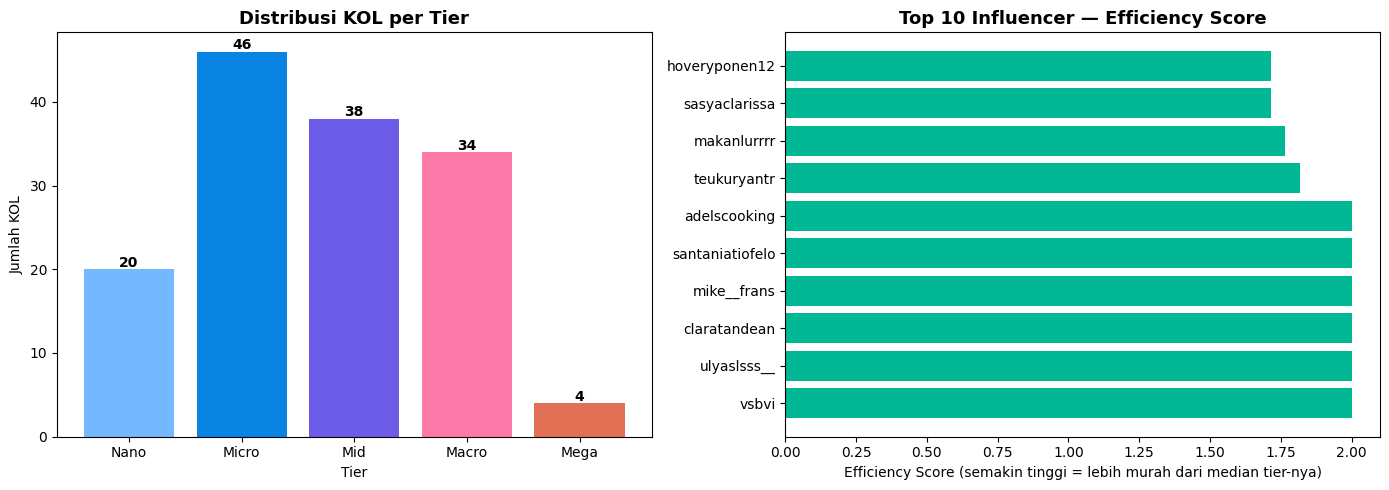

📌 Insight BQ-1:
    username_ig  tier  base_rate  efficiency_score
          vsbvi Micro    1500000                 2
    ulyaslsss__  Nano     300000                 2
   claratandean  Nano     300000                 2
    mike__frans Micro    1500000                 2
santaniatiofelo Micro    1500000                 2
   adelscooking Micro    1500000                 2
    teukuryantr   Mid    5500000                 2
    makanlurrrr Micro    1700000                 2
  sasyaclarissa  Nano     350000                 2
  hoveryponen12  Nano     350000                 2


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

tier_order  = ['Nano','Micro','Mid','Macro','Mega']
tier_colors = ['#74b9ff','#0984e3','#6c5ce7','#fd79a8','#e17055']
tier_counts = df['tier'].value_counts().reindex(tier_order)
axes[0].bar(tier_counts.index, tier_counts.values, color=tier_colors)
axes[0].set_title('Distribusi KOL per Tier', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Tier'); axes[0].set_ylabel('Jumlah KOL')
for i, v in enumerate(tier_counts.values):
    axes[0].text(i, v + 0.3, str(v), ha='center', fontweight='bold')

top_efficient = df.nlargest(10, 'efficiency_score')[['username_ig','tier','base_rate','efficiency_score']]
axes[1].barh(top_efficient['username_ig'], top_efficient['efficiency_score'], color='#00b894')
axes[1].set_title('Top 10 Influencer — Efficiency Score', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Efficiency Score (semakin tinggi = lebih murah dari median tier-nya)')
plt.tight_layout(); plt.show()

print("📌 Insight BQ-1:")
print(top_efficient.to_string(index=False))


## EDA — BQ-2: Apakah base_rate proporsional terhadap tier?

/tmp/ipykernel_1860/730972082.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='tier', y='base_rate', order=tier_order,


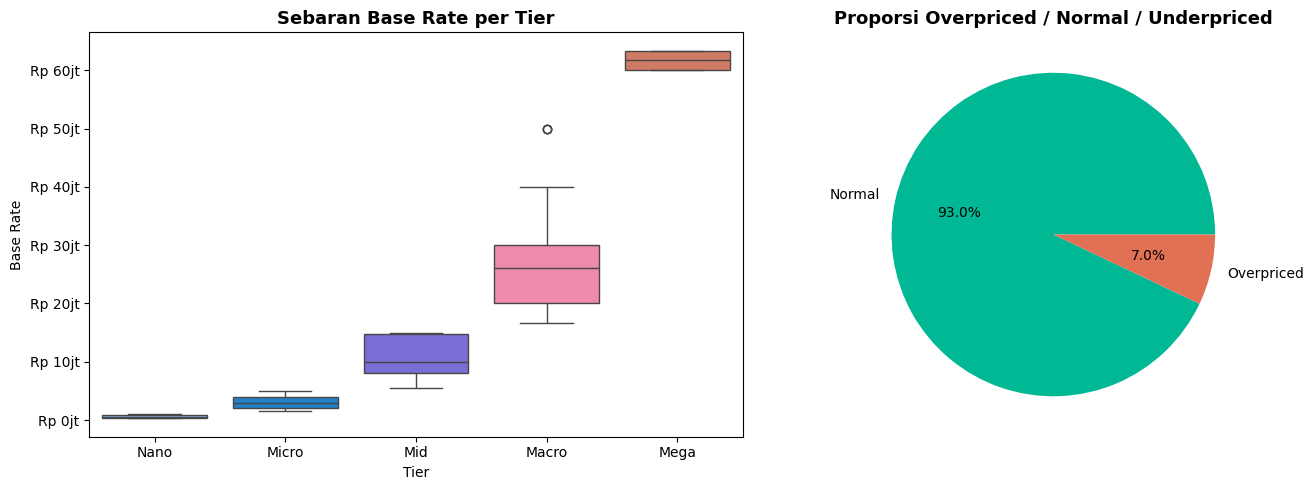


📌 Insight BQ-2 — Influencer Overpriced per Tier:
         username_ig  tier  base_rate  z_score
            annisaoy Micro    5000000        2
      faridnuralimm_ Micro    5000000        2
            cyntiaar Micro    5000000        2
         yourminbite Micro    5000000        2
        rachelvennya Macro   50000000        2
             fandidk Micro    5000000        2
        raymondchins Macro   50000000        2
            ayuwisya Micro    5000000        2
         farhanfirms Micro    5000000        2
jennifercoppenreal20 Macro   50000000        2


In [ ]:
df['z_score'] = df.groupby('tier', observed=True)['base_rate'].transform(
    lambda x: (x - x.mean()) / x.std()
)
df['price_label'] = df['z_score'].apply(
    lambda z: 'Overpriced' if z > 1.5 else ('Underpriced' if z < -1.5 else 'Normal')
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='tier', y='base_rate', order=tier_order,
            palette=tier_colors, ax=axes[0])
axes[0].set_title('Sebaran Base Rate per Tier', fontsize=13, fontweight='bold')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'Rp {x/1e6:.0f}jt'))
axes[0].set_xlabel('Tier'); axes[0].set_ylabel('Base Rate')

label_counts = df['price_label'].value_counts()
colors_label = {'Normal': '#00b894', 'Overpriced': '#e17055', 'Underpriced': '#74b9ff'}
axes[1].pie(label_counts.values, labels=label_counts.index, autopct='%1.1f%%',
            colors=[colors_label[l] for l in label_counts.index])
axes[1].set_title('Proporsi Overpriced / Normal / Underpriced', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print("\n📌 Insight BQ-2 — Influencer Overpriced per Tier:")
overpriced = df[df['price_label'] == 'Overpriced'][['username_ig','tier','base_rate','z_score']]
print(overpriced.to_string(index=False))


## EDA — BQ-3: Seberapa kompetitif nilai addon antar kategori?

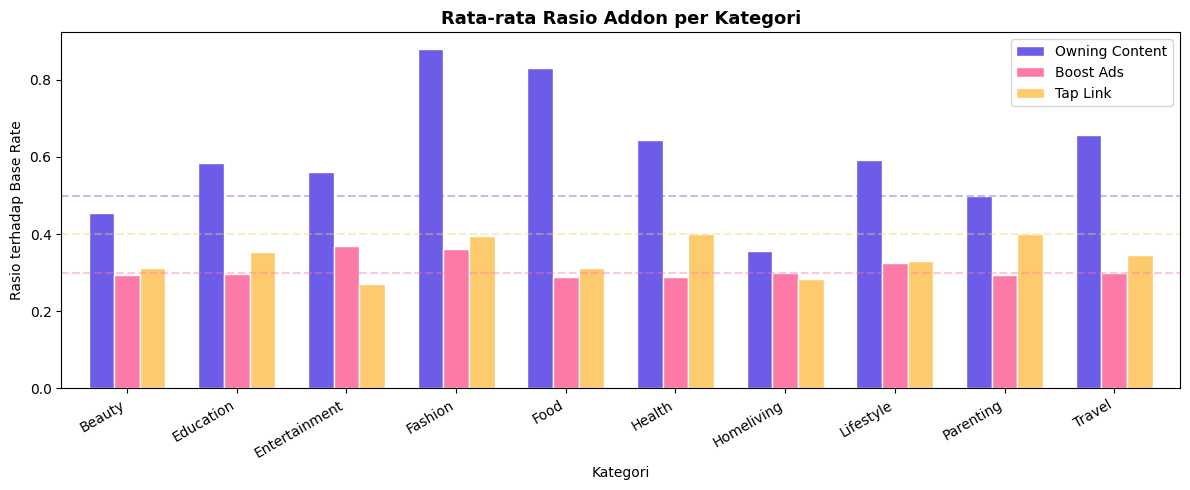


📌 Insight BQ-3 — Rata-rata Rasio Addon per Kategori:
               ratio_owning  ratio_boost  ratio_link
kategori                                            
Beauty                    0            0           0
Education                 1            0           0
Entertainment             1            0           0
Fashion                   1            0           0
Food                      1            0           0
Health                    1            0           0
Homeliving                0            0           0
Lifestyle                 1            0           0
Parenting                 0            0           0
Travel                    1            0           0


In [ ]:
addon_by_kat = df.groupby('kategori')[['ratio_owning','ratio_boost','ratio_link']].mean().round(3)

fig, ax = plt.subplots(figsize=(12, 5))
addon_by_kat.plot(kind='bar', ax=ax,
                  color=['#6c5ce7','#fd79a8','#fdcb6e'],
                  edgecolor='white', width=0.7)
ax.set_title('Rata-rata Rasio Addon per Kategori', fontsize=13, fontweight='bold')
ax.set_xlabel('Kategori'); ax.set_ylabel('Rasio terhadap Base Rate')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.legend(['Owning Content','Boost Ads','Tap Link'])
ax.axhline(y=0.5, color='#6c5ce7', linestyle='--', alpha=0.4, label='Benchmark Owning (50%)')
ax.axhline(y=0.3, color='#fd79a8', linestyle='--', alpha=0.4, label='Benchmark Boost (30%)')
ax.axhline(y=0.4, color='#fdcb6e', linestyle='--', alpha=0.4, label='Benchmark Link (40%)')
plt.tight_layout(); plt.show()

print("\n📌 Insight BQ-3 — Rata-rata Rasio Addon per Kategori:")
print(addon_by_kat.to_string())


## EDA — BQ-4: Apakah distribusi tier per kategori merata?

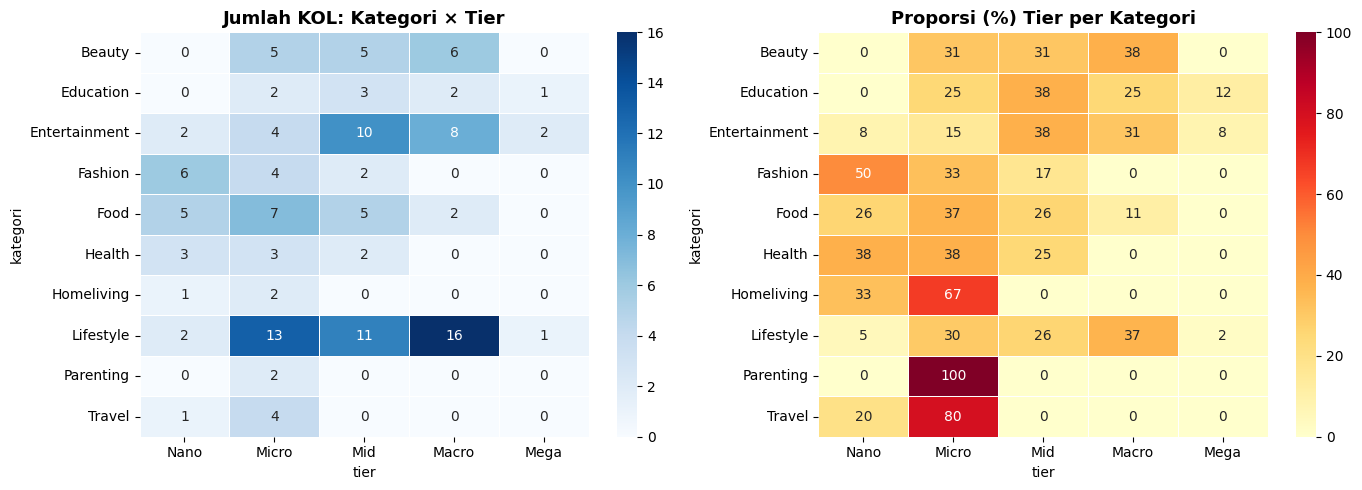


📌 Insight BQ-4 — Kategori dengan pilihan Tier terbatas (< 2 tier):
  Homeliving: hanya 2 tier tersedia
  Parenting: hanya 1 tier tersedia
  Travel: hanya 2 tier tersedia


In [ ]:
pivot = pd.crosstab(df['kategori'], df['tier'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(pivot, annot=True, fmt='d', cmap='Blues',
            linewidths=0.5, ax=axes[0])
axes[0].set_title('Jumlah KOL: Kategori × Tier', fontsize=13, fontweight='bold')

pivot_pct = pivot.div(pivot.sum(axis=1), axis=0).round(2) * 100
sns.heatmap(pivot_pct, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, ax=axes[1])
axes[1].set_title('Proporsi (%) Tier per Kategori', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print("\n📌 Insight BQ-4 — Kategori dengan pilihan Tier terbatas (< 2 tier):")
for kat in pivot.index:
    tiers_available = (pivot.loc[kat] > 0).sum()
    if tiers_available <= 2:
        print(f"  {kat}: hanya {tiers_available} tier tersedia")


## EDA — BQ-5: Simulasi alokasi budget

💰 Budget: Rp 50,000,000

Skenario                        Jml KOL        Total Biaya
------------------------------------------------------------
Skenario A — Full Micro              22 Rp      48,579,999
  → vsbvi, mike__frans, santaniatiofelo, adelscooking, makanlurrrr...

Skenario B — Mix Mid+Micro           22 Rp      48,579,999
  → santaniatiofelo, mike__frans, vsbvi, adelscooking, makanlurrrr...

Skenario C — 1 Macro                  2 Rp      33,666,666
  → utepsunarya, gilangsamiadji



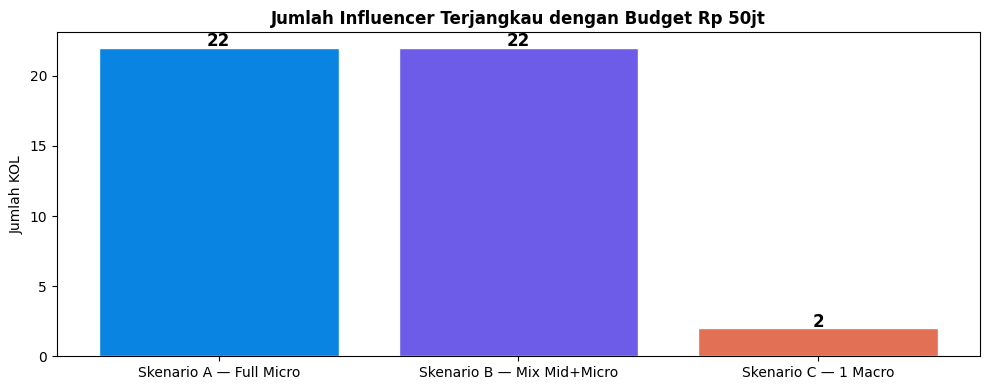

In [ ]:
def simulate_budget(budget, tier_filter):
    """Hitung berapa influencer yang bisa dijangkau dengan budget tertentu."""
    pool   = df[df['tier'].isin(tier_filter)].sort_values('base_rate')
    total  = 0
    count  = 0
    chosen = []
    for _, row in pool.iterrows():
        if total + row['base_rate'] <= budget:
            total += row['base_rate']
            count += 1
            chosen.append(row['username_ig'])
    return count, total, chosen

BUDGET = 50_000_000

skenario = {
    'Skenario A — Full Micro'   : simulate_budget(BUDGET, ['Micro']),
    'Skenario B — Mix Mid+Micro': simulate_budget(BUDGET, ['Mid','Micro']),
    'Skenario C — 1 Macro'      : simulate_budget(BUDGET, ['Macro']),
}

print(f"💰 Budget: Rp {BUDGET:,.0f}\n")
print(f"{'Skenario':<30} {'Jml KOL':>8} {'Total Biaya':>18}")
print("-" * 60)
for nama, (count, total, chosen) in skenario.items():
    print(f"{nama:<30} {count:>8} Rp {total:>15,.0f}")
    print(f"  → {', '.join(chosen[:5])}{'...' if len(chosen) > 5 else ''}")
    print()

fig, ax = plt.subplots(figsize=(10, 4))
names  = list(skenario.keys())
counts = [v[0] for v in skenario.values()]
colors = ['#0984e3','#6c5ce7','#e17055']
ax.bar(names, counts, color=colors, edgecolor='white')
ax.set_title(f'Jumlah Influencer Terjangkau dengan Budget Rp {BUDGET/1e6:.0f}jt',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Jumlah KOL')
for i, v in enumerate(counts):
    ax.text(i, v + 0.1, str(v), ha='center', fontweight='bold', fontsize=12)
plt.tight_layout(); plt.show()


---
# Tahap 7 — A/B Testing
> Menguji apakah ada perbedaan signifikan antara dua kelompok influencer menggunakan uji statistik.

**Hipotesis:**
- **H₀:** Tidak ada perbedaan `ratio_post` antara influencer tier Micro dan Macro
- **H₁:** Terdapat perbedaan signifikan (α = 0.05)

**Rasionalisasi:** Jika Micro dan Macro memiliki `ratio_post` yang berbeda, ini berarti harga relatif format Reels tidak konsisten antar tier — informasi penting untuk UMKM dalam menegosiasikan harga.


Jumlah sampel — Micro: 46 | Macro: 34
Mean ratio_post — Micro: 1.7603 | Macro: 1.4898

Uji Normalitas Shapiro-Wilk:
  Micro p=0.4875 (Normal ✅)
  Macro p=0.0000 (Tidak Normal ❌)

📊 Hasil Mann-Whitney U:
   Statistic : 1059.5000
   p-value   : 0.0070
   Kesimpulan: ✅ H₀ DITOLAK — ada perbedaan signifikan


/tmp/ipykernel_1860/3251803179.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot([group_micro, group_macro], labels=['Micro','Macro'],


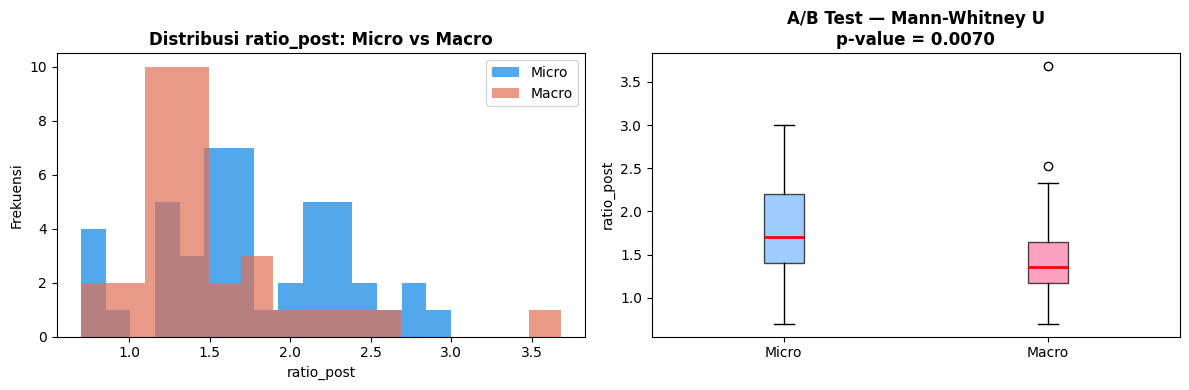

In [ ]:
group_micro = df[df['tier'] == 'Micro']['ratio_post'].dropna()
group_macro = df[df['tier'] == 'Macro']['ratio_post'].dropna()

print(f"Jumlah sampel — Micro: {len(group_micro)} | Macro: {len(group_macro)}")
print(f"Mean ratio_post — Micro: {group_micro.mean():.4f} | Macro: {group_macro.mean():.4f}")

_, p_micro = stats.shapiro(group_micro)
_, p_macro = stats.shapiro(group_macro)
print(f"\nUji Normalitas Shapiro-Wilk:")
print(f"  Micro p={p_micro:.4f} {'(Normal ✅)' if p_micro > 0.05 else '(Tidak Normal ❌)'}")
print(f"  Macro p={p_macro:.4f} {'(Normal ✅)' if p_macro > 0.05 else '(Tidak Normal ❌)'}")

if p_micro > 0.05 and p_macro > 0.05:
    stat, p_val = stats.ttest_ind(group_micro, group_macro)
    uji = "Independent t-test"
else:
    stat, p_val = stats.mannwhitneyu(group_micro, group_macro, alternative='two-sided')
    uji = "Mann-Whitney U"

print(f"\n📊 Hasil {uji}:")
print(f"   Statistic : {stat:.4f}")
print(f"   p-value   : {p_val:.4f}")
print(f"   Kesimpulan: {'✅ H₀ DITOLAK — ada perbedaan signifikan' if p_val < 0.05 else '❌ H₀ GAGAL DITOLAK — tidak ada perbedaan signifikan'}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(group_micro, bins=15, alpha=0.7, label='Micro', color='#0984e3')
axes[0].hist(group_macro, bins=15, alpha=0.7, label='Macro', color='#e17055')
axes[0].set_title('Distribusi ratio_post: Micro vs Macro', fontweight='bold')
axes[0].set_xlabel('ratio_post'); axes[0].set_ylabel('Frekuensi')
axes[0].legend()

bp = axes[1].boxplot([group_micro, group_macro], labels=['Micro','Macro'],
                     patch_artist=True,
                     boxprops=dict(facecolor='#74b9ff', alpha=0.7),
                     medianprops=dict(color='red', linewidth=2))
bp['boxes'][1].set_facecolor('#fd79a8')
axes[1].set_title(f'A/B Test — {uji}\np-value = {p_val:.4f}', fontweight='bold')
axes[1].set_ylabel('ratio_post')
plt.tight_layout(); plt.show()


---
# Tahap 8 — Dashboard & Deployment

## Streamlit Dashboard
Dashboard interaktif telah dikembangkan menggunakan **Streamlit** di VS Code dan di-deploy ke Streamlit Cloud.

- 🔗 **Link Dashboard:** *https://capstone-project-data-science---cc26-psu142-pwqyedrdtfocbu2mxl.streamlit.app/*
- 📁 **Repository GitHub:** *https://github.com/nafisfhkr/Capstone-Project-Data-Science---CC26-PSU142*

**Fitur dashboard:**
- Filter influencer berdasarkan kategori, tier, dan budget
- Visualisasi distribusi rate dan tier
- Simulasi alokasi budget interaktif
- Tabel rekomendasi influencer
---